### Solving the geodynamo inverse problem using PiNNs in the spectral domain

In [1]:
import torch
import numpy
import pygeotools
import scipy

In [2]:
pygeo = pygeotools.pygeotools()

pygeotools was initialized with `verbose=True`.


#### 1. Data

In [3]:
# Loading the model
pygeo.loadModel("geodynamo", "pygeodyn_hdf5", "geodynamo.hdf5")

In [4]:
# Defining the spatial grid
grid_size = 3

if not pygeo.isGrid(f"{grid_size}deg"):
    pygeo.addGrid(f"{grid_size}deg", grid_size, grid_size)

pygeo.setGrid(f"{grid_size}deg")

_, (thetas, phis) = pygeo.getCurrentGrid()

In [5]:
# Defining the contexts
context_sv = {"r": pygeo.constants["rCore"], "lmax": 13}
context_mf = {"r": pygeo.constants["rCore"], "lmax": 13}
context_u = {"r": pygeo.constants["rCore"], "lmax": 18}

In [6]:
# Computing the fields
SV = pygeo.addMeasure("geodynamo", "SV", context_sv)
MF = pygeo.addMeasure("geodynamo", "MF", context_mf)
U = pygeo.addMeasure("geodynamo", "U", context_u)

13


In [7]:
# Selecting the data
dbrdt_obs = SV[0, ..., 0]
br_obs = MF[0, ..., 0]
uθ_obs = U[0, ..., 1]
uφ_obs = U[0, ..., 2]

#### 2. Neural network

In [8]:
class Sine(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.sin(x)

class network(torch.nn.Module):
    def __init__(self, nb_inputs: int = 1, nb_outputs: int = 10, nb_layers: int = 5, nb_neurons: int = 16) -> None:
        super().__init__()

        layers = []

        # Creating the first layer
        layers.append(torch.nn.Linear(nb_inputs, nb_neurons))
        layers.append(Sine())

        # Creating the hidden layers
        for _ in range(nb_layers):
            layers.append(torch.nn.Linear(nb_neurons, nb_neurons))
            layers.append(Sine())

        # Creating the last layer
        layers.append(torch.nn.Linear(nb_neurons, nb_outputs))

        self.net = torch.nn.Sequential(*layers)

    def forward(self, x) -> torch.Tensor:
        return self.net(x)

In [26]:
net = network(1, 2 * 14**2, 10, 2 * 14**2 // 10)

In [27]:
net

network(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=39, bias=True)
    (1): Sine()
    (2): Linear(in_features=39, out_features=39, bias=True)
    (3): Sine()
    (4): Linear(in_features=39, out_features=39, bias=True)
    (5): Sine()
    (6): Linear(in_features=39, out_features=39, bias=True)
    (7): Sine()
    (8): Linear(in_features=39, out_features=39, bias=True)
    (9): Sine()
    (10): Linear(in_features=39, out_features=39, bias=True)
    (11): Sine()
    (12): Linear(in_features=39, out_features=39, bias=True)
    (13): Sine()
    (14): Linear(in_features=39, out_features=39, bias=True)
    (15): Sine()
    (16): Linear(in_features=39, out_features=39, bias=True)
    (17): Sine()
    (18): Linear(in_features=39, out_features=39, bias=True)
    (19): Sine()
    (20): Linear(in_features=39, out_features=39, bias=True)
    (21): Sine()
    (22): Linear(in_features=39, out_features=392, bias=True)
  )
)

#### 3. Spherical harmonics and operators

In [28]:
def compute_spherical_harmonics(thetas, phis, lmax = 13):
    l = numpy.arange(0, lmax + 1, 1)
    L, M = numpy.meshgrid(l, l, indexing="ij")

    θ, φ = numpy.meshgrid(thetas, phis, indexing="ij")
    cosθ = numpy.cos(θ)
    sinθ = numpy.sin(θ)

    mφ = numpy.einsum("ij,kl->ijkl", M, φ)

    cosmφ = numpy.cos(mφ)
    sinmφ = numpy.sin(mφ)

    def δ(x):
        return numpy.array(x == 0, dtype=numpy.float64)
    
    def Γ(x):
        return scipy.special.factorial(x)
    
    schmidt = (-1)**M * numpy.sqrt((2 - δ(M)) * Γ(L - M) / Γ(L + M))

    p, dp = scipy.special.assoc_legendre_p_all(lmax, lmax, cosθ, diff_n=1)
    p = p[:,:(lmax+1),...]
    dp = -dp[:,:(lmax+1),...] * sinθ # Chain rule: dP/dθ = dP/dz dz/dθ = -sinθ dP/dz (with z = cosθ)

    p = numpy.einsum("ij,ijkl->ijkl", schmidt, p)
    dp = numpy.einsum("ij,ijkl->ijkl", schmidt, dp)

    ycos, ysin = p * cosmφ, p * sinmφ

    dycosdθ, dysindθ = dp * cosmφ, dp * sinmφ
    dycosdφ = numpy.einsum("ij,ijkl", -M, p * sinmφ)
    dysindφ = numpy.einsum("ij,ijkl", M, p * cosmφ)

    return ycos, ysin, \
        dycosdθ, dysindθ, dycosdφ, dysindφ

In [29]:
ycos, ysin, \
dycosdθ, dysindθ, \
dycosdφ, dysindφ = compute_spherical_harmonics(thetas, phis, 13)

In [30]:
rC = pygeo.constants["rCore"]
rE = pygeo.constants["rEarth"]

In [31]:
def H_br(lmax = 13):
    l = numpy.arange(0, lmax + 1, 1)
    L, M = numpy.meshgrid(l, l, indexing="ij")

    H_cos = numpy.einsum("ij,ijkl->ijkl", (L + 1) * (rE / rC)**(L + 2), ycos)
    H_sin = numpy.einsum("ij,ijkl->ijkl", (L + 1) * (rE / rC)**(L + 2), ysin)

    return H_cos, H_sin

#### 4. Coefficients

In [32]:
coeffs_sv = pygeo.getQuantity("geodynamo", "SV")[0]
coeffs_mf = pygeo.getQuantity("geodynamo", "MF")[0]

gnm = numpy.zeros((14, 14))
hnm = numpy.zeros((14, 14))

dgnm = numpy.zeros((14, 14))
dhnm = numpy.zeros((14, 14))

k = 0

for l in range(1, 13 + 1):
    for m in range(0, l + 1):
        gnm[l,m] = coeffs_mf[k]
        dgnm[l,m] = coeffs_sv[k]
        k += 1
        if m != 0:
            hnm[l,m] = coeffs_mf[k]
            dhnm[l,m] = coeffs_sv[k]
            k += 1

In [33]:
H_br_cos, H_br_sin = H_br(13)

br_calc = numpy.tensordot(gnm, H_br_cos, axes=2) + numpy.tensordot(hnm, H_br_sin, axes=2)

sv_calc = numpy.einsum("ij,ijkl->kl", dgnm, H_br_cos) + \
    numpy.einsum("ij,ijkl->kl", dhnm, H_br_sin)

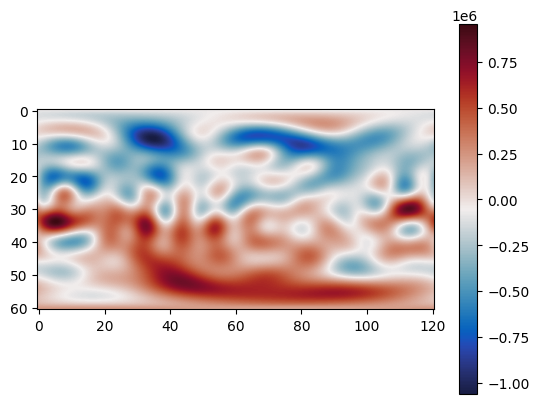

In [34]:
import matplotlib.pyplot as plt
import cmocean

kwargs = {
    "cmap": cmocean.cm.balance, "interpolation": "lanczos"
}

plt.imshow(br_calc, **kwargs)
plt.colorbar()

#### 5. Training

In [35]:
H_br_cos_tensor = torch.tensor(H_br_cos, dtype=torch.float32)
H_br_sin_tensor = torch.tensor(H_br_sin, dtype=torch.float32)

In [36]:
br_obs_tensor = torch.tensor(br_obs, dtype=torch.float32)

In [37]:
# Generating a random vector
t_input = torch.tensor(numpy.array([1]).reshape(-1, 1), dtype=torch.float32, requires_grad=True)

In [38]:
def compute_loss(x, eval=False):
    coeffs = net(x)

    kmax = coeffs.shape[-1] // 2

    gnm = coeffs[:,:kmax].reshape(14, 14)
    hnm = coeffs[:,kmax:].reshape(14, 14)

    br_calc = torch.tensordot(gnm, H_br_cos_tensor, dims=2) + \
        torch.tensordot(hnm, H_br_sin_tensor, dims=2)
    
    if eval:
        return gnm, hnm, br_calc
    
    return ((br_obs_tensor - br_calc).pow(2) / br_obs_tensor.pow(2)).mean()

In [39]:
optim = torch.optim.AdamW(net.parameters())

best = 1e99

for epoch in range(10000):

    optim.zero_grad(True)

    loss = compute_loss(t_input)
    loss.backward()

    if loss.item() < best:
        best = loss.item()

    if epoch % 100 == 0:
        print(f"{best:.3E}")

    optim.step()

1.568E+01
1.063E+00
1.012E+00
9.933E-01
9.813E-01
9.709E-01
9.629E-01
9.565E-01
9.513E-01
9.458E-01
9.423E-01
9.361E-01
9.344E-01
9.284E-01
9.284E-01
9.229E-01
9.197E-01
9.162E-01
9.145E-01
9.110E-01
9.075E-01
9.065E-01
9.027E-01
9.020E-01
8.989E-01
8.958E-01
8.956E-01
8.921E-01
8.902E-01
8.884E-01
8.850E-01
8.848E-01
8.818E-01
8.801E-01
8.777E-01
8.766E-01
8.748E-01
8.727E-01
8.709E-01
8.700E-01
8.679E-01
8.662E-01
8.653E-01
8.630E-01
8.626E-01
8.603E-01
8.599E-01
8.579E-01
8.567E-01
8.551E-01
8.543E-01
8.525E-01
8.521E-01
8.501E-01
8.490E-01
8.488E-01
8.468E-01
8.459E-01
8.453E-01
8.435E-01
8.430E-01
8.415E-01
8.409E-01
8.395E-01
8.386E-01
8.379E-01
8.366E-01
8.360E-01
8.348E-01
8.337E-01
8.335E-01
8.322E-01
8.315E-01
8.300E-01
8.299E-01
8.283E-01
8.282E-01
8.271E-01
8.262E-01
8.249E-01
8.245E-01
8.237E-01
8.229E-01
8.221E-01
8.214E-01
8.207E-01
8.199E-01
8.193E-01
8.186E-01
8.179E-01
8.171E-01
8.165E-01
8.156E-01
8.149E-01
8.145E-01
8.135E-01
8.131E-01
8.123E-01
8.119E-01
8.111E-01


In [40]:
gnm_calc, hnm_calc, br_calc = compute_loss(t_input, eval=True)

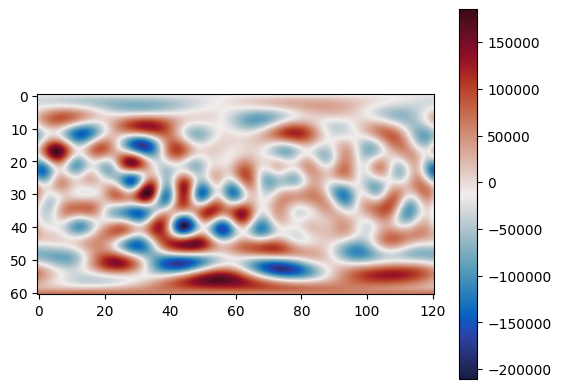

In [42]:
br_calc_numpy = br_calc.detach().clone().numpy()

plt.imshow(br_calc_numpy, **kwargs)
plt.colorbar()